<a href="https://colab.research.google.com/github/ThejeshMundlapati/CS6220-Data-Mining/blob/main/homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 6220 - Homework 1: Environment Setup & Iris Pipeline

**Name:** Thejesh Mundlapati  
**Course:** CS 6220 - Data Mining  
**Environment:** Python 3 + scikit-learn, running in **Google Colab** (in the browser).

This notebook sets up a data-mining environment and tests it on the classic Iris flower dataset. It:
1. Loads the Iris data directly from the UCI Machine Learning Repository.
2. Splits it into 80% training / 20% test data.
3. Builds a scikit-learn `Pipeline` (standardization + a classifier).
4. Trains the model, evaluates it on the test set, and reports accuracy.
5. Measures training time and testing time.



## 1. Environment setup and imports

Colab already includes NumPy, pandas, scikit-learn, and matplotlib. We only need to install `ucimlrepo`, the official helper for downloading datasets from the UCI repository.

In [1]:
# Install the UCI dataset helper (already-installed packages are skipped).
!pip install -q ucimlrepo

import sys, time
import numpy as np
import pandas as pd
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Print versions -- handy evidence for the "describe your environment" question.
print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python      : 3.13.15
NumPy       : 2.1.3
pandas      : 2.2.3
scikit-learn: 1.6.1


## 2. Load the Iris dataset (from UCI)

We fetch the dataset by its UCI id (`53`). `ucimlrepo` returns the features and target as pandas DataFrames.

If the UCI download ever fails (e.g., the site is temporarily down), use the fallback cell below to load the identical dataset from scikit-learn instead.

In [2]:
from ucimlrepo import fetch_ucirepo

# Fetch the Iris dataset (UCI id 53).
iris = fetch_ucirepo(id=53)

X = iris.data.features          # 4 numeric feature columns
y = iris.data.targets["class"]  # the class label (a single column)

print("Feature shape:", X.shape)
print("Target shape :", y.shape)
X.head()

Feature shape: (150, 4)
Target shape : (150,)


,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# How many samples per class? Iris is balanced: 50 of each.
print(y.value_counts())

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### (Fallback) Load the same data from scikit-learn

Only use this if the UCI download above fails. It produces the same 150 rows and 4 features (labels are 0/1/2 instead of the species names).

In [ ]:
# from sklearn.datasets import load_iris
# bunch = load_iris(as_frame=True)
# X = bunch.data
# y = bunch.target
# print(X.shape, y.shape)

## 3. (Optional) Quick visualization

A scatterplot similar to the ones on the Iris Wikipedia page. Petal length vs. petal width separates the three species well.

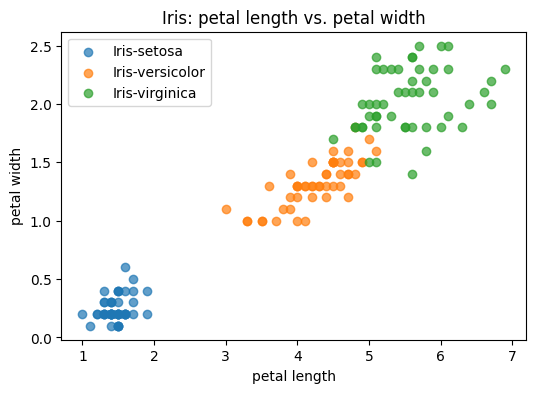

In [4]:
import matplotlib.pyplot as plt

# Combine features + labels for easy plotting.
plot_df = X.copy()
plot_df["class"] = y.values

plt.figure(figsize=(6, 4))
for species, group in plot_df.groupby("class"):
    plt.scatter(group.iloc[:, 2], group.iloc[:, 3], label=species, alpha=0.7)
plt.xlabel(X.columns[2])   # petal length
plt.ylabel(X.columns[3])   # petal width
plt.title("Iris: petal length vs. petal width")
plt.legend()
plt.show()

## 4. Train / test split (80% / 20%)

We use scikit-learn's `train_test_split`. `stratify=y` keeps the class proportions balanced in both sets, and `random_state=42` makes the split reproducible.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # reproducible split
    stratify=y           # keep class balance
)

print("Training samples:", X_train.shape[0])
print("Test samples    :", X_test.shape[0])

Training samples: 120
Test samples    : 30


## 5. Build the pipeline

We use the scikit-learn `Pipeline` abstraction with two steps:
1. `StandardScaler` -- standardizes each feature (mean 0, variance 1).
2. `LogisticRegression` -- a simple, solid multi-class classifier.

Bundling these in a `Pipeline` means the scaler is fit **only** on the training data and then applied consistently to the test data, which avoids data leakage.

In [6]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])
pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000))])

## 6. Helper function -- timed training

We put the training logic in its own function and instrument it with a timer, so we can report the training running time (Question 6a).

In [7]:
def train_model(pipeline, X_train, y_train):
    """Fit the pipeline and return (fitted_pipeline, elapsed_seconds)."""
    start = time.perf_counter()
    pipeline.fit(X_train, y_train)
    elapsed = time.perf_counter() - start
    return pipeline, elapsed

In [8]:
# Quick sanity test of the helper on a small subset.
# The split is shuffled, so the first 20 rows contain multiple classes.
# Expected: a fitted pipeline is returned and the elapsed time is positive.
_probe = Pipeline([("scaler", StandardScaler()),
                   ("clf", LogisticRegression(max_iter=1000))])
_fitted, _t = train_model(_probe, X_train[:20], y_train[:20])
print("Returned a fitted pipeline:", hasattr(_fitted, "predict"))
print("Elapsed seconds > 0       :", _t > 0)

Returned a fitted pipeline: True
Elapsed seconds > 0       : True


## 7. Helper function -- timed evaluation

Similarly, evaluation gets its own timed function so we can report the testing running time (Question 6b) and the accuracy (Question 6c).

In [9]:
def evaluate_model(model, X_test, y_test):
    """Predict on the test set; return (accuracy, elapsed_seconds, predictions)."""
    start = time.perf_counter()
    y_pred = model.predict(X_test)
    elapsed = time.perf_counter() - start
    acc = accuracy_score(y_test, y_pred)
    return acc, elapsed, y_pred

In [10]:
# Sanity test: accuracy should be a float in [0, 1].
_acc, _t2, _pred = evaluate_model(_fitted, X_test[:20], y_test[:20])
print("Accuracy is between 0 and 1:", 0.0 <= _acc <= 1.0)
print("Elapsed seconds >= 0       :", _t2 >= 0)

Accuracy is between 0 and 1: True
Elapsed seconds >= 0       : True


## 8. Run it -- train, evaluate, and report

This is the main experiment used for the report (Questions 6a-6c).

In [11]:
# Train
model, train_time = train_model(pipeline, X_train, y_train)

# Evaluate
accuracy, test_time, y_pred = evaluate_model(model, X_test, y_test)

print(f"Training time : {train_time:.5f} seconds")
print(f"Testing time  : {test_time:.5f} seconds")
print(f"Test accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")

Training time : 0.01273 seconds
Testing time  : 0.00215 seconds
Test accuracy : 0.9333  (93.33%)


## 9. (Optional) Confusion matrix and per-class report

Shows where the model made mistakes across the three species.

In [12]:
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

Confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Classification report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



## 10. (Optional) Hyperparameter exploration

We vary the logistic-regression regularization strength `C` and see how test accuracy changes. Larger `C` means weaker regularization.

In [13]:
for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    trial = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, C=C)),
    ])
    trial.fit(X_train, y_train)
    acc = accuracy_score(y_test, trial.predict(X_test))
    print(f"C = {C:6.2f}  ->  test accuracy = {acc:.4f}")

C =   0.01  ->  test accuracy = 0.8000
C =   0.10  ->  test accuracy = 0.8667
C =   1.00  ->  test accuracy = 0.9333
C =  10.00  ->  test accuracy = 1.0000
C = 100.00  ->  test accuracy = 1.0000


## 11. Summary of results (for the report)

| Metric | Value |
|---|---|
| Model | Logistic Regression (with StandardScaler) |
| Train/test split | 80% / 20% (stratified) |
| Training time | 0.01273 seconds |
| Testing time | 0.00215 seconds |
| Test accuracy | 0.9333  (93.33%) |

